In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

## GRU

### Battery Drain Comparison

#### Statistics

In [2]:
df = pd.read_csv("./API_GRU.csv")
df.head()

,timestamp,cpu_usage,memory_usage,temperature,battery_level,battery_charging,upload_speed_kbps,download_speed_kbps,screen_on,brightness,battery_drain,predicted_drain_average,inference_time_ms,batch
0,5/1/2026 10:38,55,65,38.0,50,0,8.770573,122.754200,1,23,-660,-333.01575,4169.728176,1
1,5/1/2026 10:38,55,65,38.0,50,0,8.770573,122.754200,1,23,-660,-336.80630,176.724687,1
2,5/1/2026 10:38,42,66,38.0,50,0,8.381533,59.084347,1,23,-390,-342.35532,176.040885,1
3,5/1/2026 10:38,39,66,38.0,50,0,3.413585,53.422348,1,23,-395,-344.14853,139.490208,1
4,5/1/2026 10:38,35,67,38.0,50,0,6.425407,108.144870,1,23,-286,-345.38885,118.480416,1


In [3]:
shift_step = 15
df_eval = df.copy()
df_eval['actual_aligned'] = (
    df_eval.groupby('batch')['battery_drain']
    .shift(-shift_step)
)
df_eval = df_eval.dropna(
    subset=['actual_aligned', 'predicted_drain_average']
)

In [4]:
df_eval[['actual_aligned', 'predicted_drain_average']].mean()

actual_aligned             81.994914
predicted_drain_average    21.233591
dtype: float64

In [5]:
# Not Charging
df_eval[df_eval['battery_charging'] != 1][
    ['actual_aligned', 'predicted_drain_average']
].mean()

actual_aligned            -270.611452
predicted_drain_average   -340.958100
dtype: float64

In [6]:
# Charging
df_eval[df_eval['battery_charging'] == 1][
    ['actual_aligned', 'predicted_drain_average']
].mean()

actual_aligned             1803.523296
predicted_drain_average    1789.560362
dtype: float64

In [7]:
charging = df_eval[df_eval['battery_charging'] == 1]
not_charging = df_eval[df_eval['battery_charging'] != 1]

In [8]:
def evaluate_prediction(df_input):
    actual_result = df_input['actual_aligned']
    predicted_result = df_input['predicted_drain_average']

    mse = mean_squared_error(actual_result, predicted_result)
    rmse = root_mean_squared_error(actual_result, predicted_result)
    r2 = r2_score(actual_result, predicted_result)

    return {
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

In [9]:
result = evaluate_prediction(df_eval)
result_charging = evaluate_prediction(charging)
result_not_charging = evaluate_prediction(not_charging)

In [10]:
print("=== All ===")
print(f"MSE  : {result['MSE']:.4f}")
print(f"RMSE : {result['RMSE']:.4f}")
print(f"R2   : {result['R2']:.4f}")

print("\n=== Charging ===")
print(f"MSE  : {result_charging['MSE']:.4f}")
print(f"RMSE : {result_charging['RMSE']:.4f}")
print(f"R2   : {result_charging['R2']:.4f}")

print("\n=== Not Charging ===")
print(f"MSE  : {result_not_charging['MSE']:.4f}")
print(f"RMSE : {result_not_charging['RMSE']:.4f}")
print(f"R2   : {result_not_charging['R2']:.4f}")

=== All ===
MSE  : 272398.5917
RMSE : 521.9182
R2   : 0.7119

=== Charging ===
MSE  : 915107.1348
RMSE : 956.6123
R2   : 0.2979

=== Not Charging ===
MSE  : 140757.9368
RMSE : 375.1772
R2   : 0.0017


#### Graph

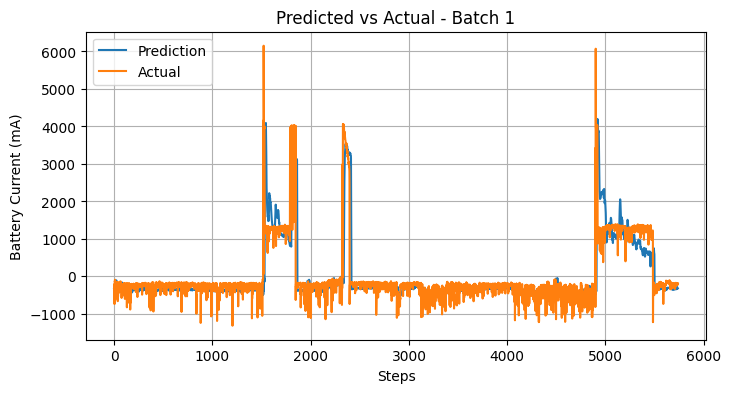

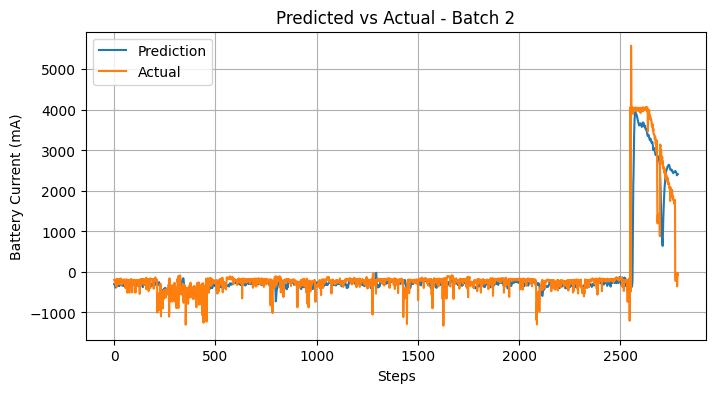

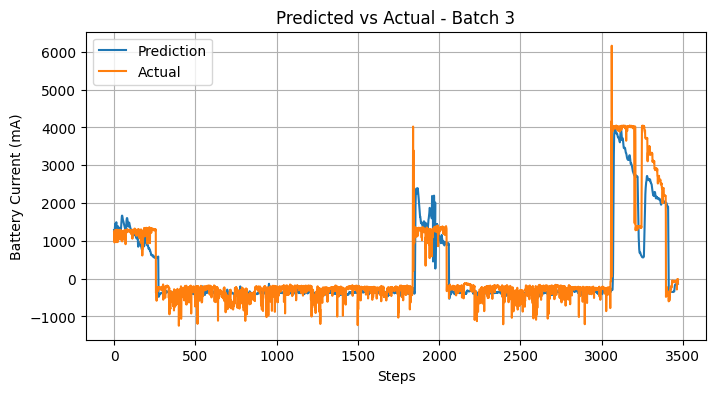

In [11]:
# Predicted vs Actual Graph
batch_num = df['batch'].nunique()

for i in range(1, batch_num + 1):
    batch_df = df[df['batch'] == i].copy()

    actual = batch_df['battery_drain'].shift(-shift_step)
    predicted = batch_df['predicted_drain_average']

    valid_idx = actual.notna()
    actual = actual[valid_idx].values
    predicted = predicted[valid_idx].values

    plt.figure(figsize=(8, 4))
    plt.plot(predicted, label="Prediction")
    plt.plot(actual, label="Actual")
    plt.title(f"Predicted vs Actual - Batch {i}")
    plt.xlabel("Steps")
    plt.ylabel("Battery Current (mA)")
    plt.legend()
    plt.grid(True)
    plt.show()

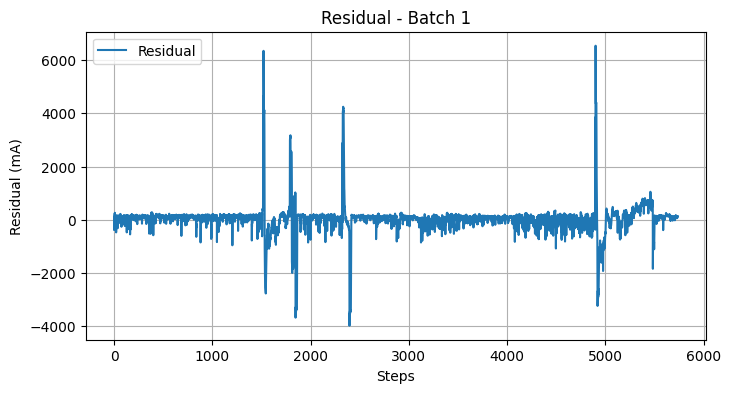

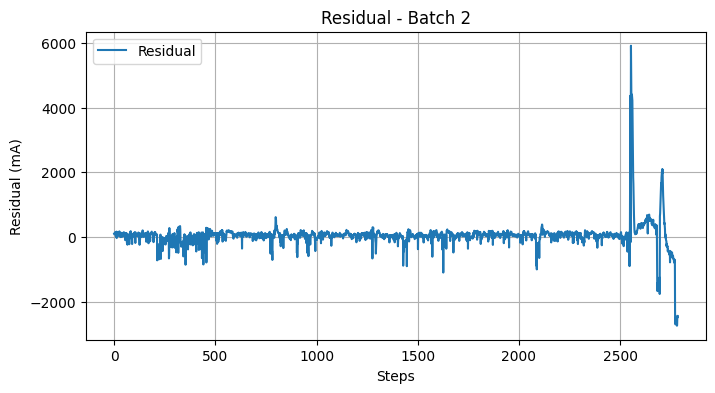

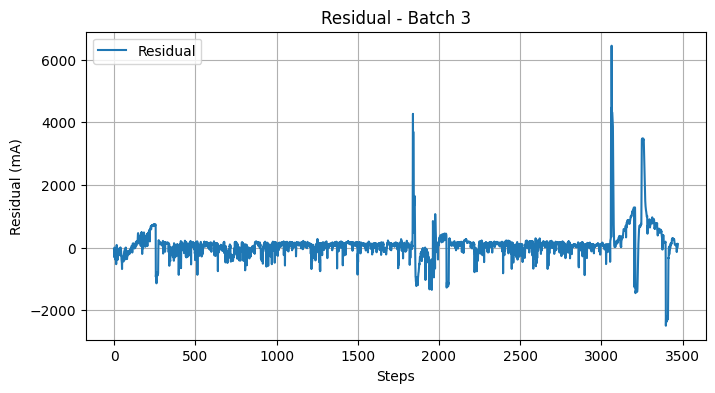

In [12]:
# Residual Graph
for i in range(1, batch_num + 1):
    batch_df = df[df['batch'] == i].copy()

    actual = batch_df['battery_drain'].shift(-shift_step)
    predicted = batch_df['predicted_drain_average']

    valid_idx = actual.notna()
    actual = actual[valid_idx].values
    predicted = predicted[valid_idx].values

    residual = actual - predicted

    plt.figure(figsize=(8, 4))
    plt.plot(residual, label="Residual")
    plt.title(f"Residual - Batch {i}")
    plt.xlabel("Steps")
    plt.ylabel("Residual (mA)")
    plt.legend()
    plt.grid(True)
    plt.show()

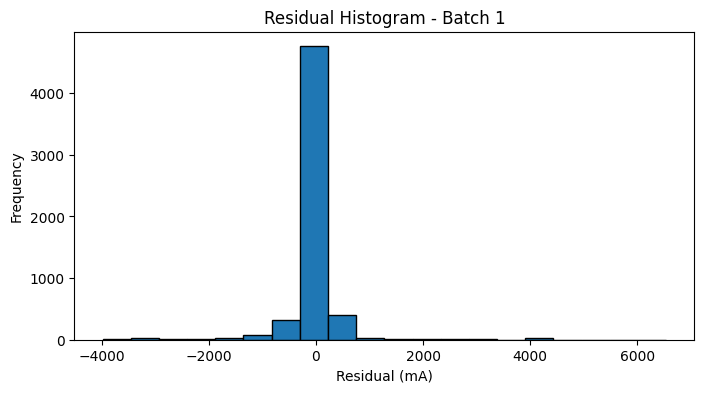

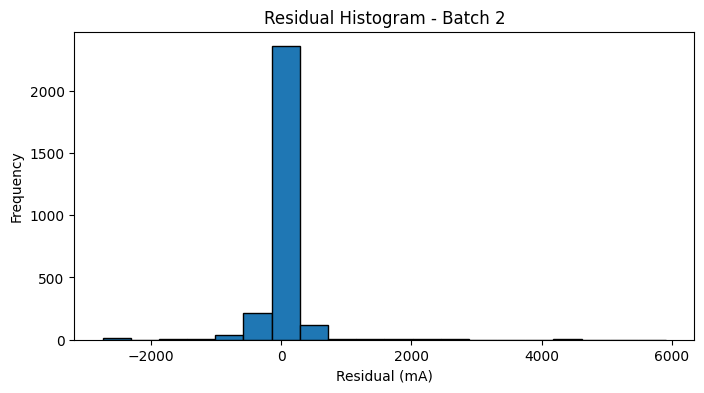

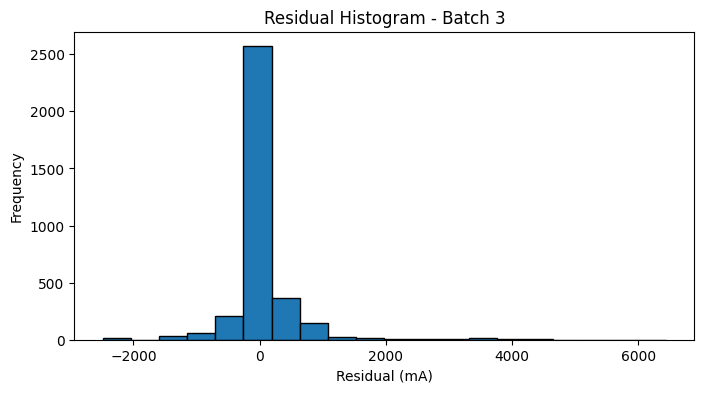

In [13]:
#Residual Histogram
for i in range(1, batch_num + 1):
    batch_df = df[df['batch'] == i].copy()

    actual = batch_df['battery_drain'].shift(-shift_step)
    predicted = batch_df['predicted_drain_average']

    valid_idx = actual.notna()
    actual = actual[valid_idx].values
    predicted = predicted[valid_idx].values

    residual = actual - predicted

    plt.figure(figsize=(8, 4))
    plt.hist(residual, bins=20, edgecolor='black')
    plt.xlabel("Residual (mA)")
    plt.ylabel("Frequency")
    plt.title(f"Residual Histogram - Batch {i}")

Correlation: 0.853201499978124


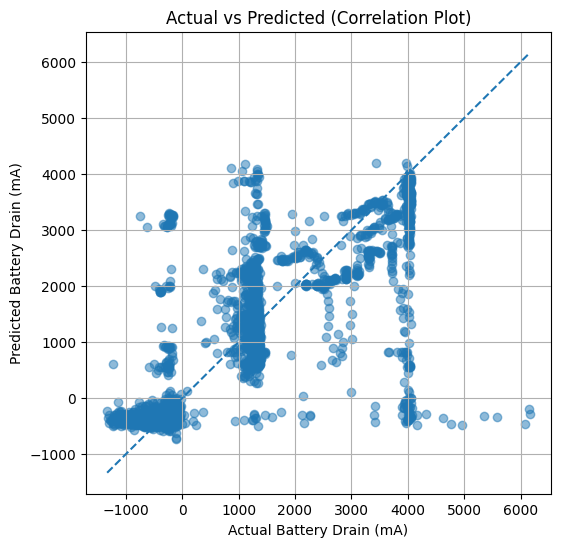

In [14]:
# Scatter Plot
actual_all = df_eval['battery_drain'].shift(-shift_step)
predicted_all = df_eval['predicted_drain_average']

valid_idx = actual_all.notna()
actual_all = actual_all[valid_idx].values
predicted_all = predicted_all[valid_idx].values

plt.figure(figsize=(6,6))
plt.scatter(actual_all, predicted_all, alpha=0.5)
min_val = min(actual_all.min(), predicted_all.min())
max_val = max(actual_all.max(), predicted_all.max())
plt.xlabel("Actual Battery Drain (mA)")
plt.ylabel("Predicted Battery Drain (mA)")
plt.title("Actual vs Predicted (Correlation Plot)")
plt.grid(True)
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')
print("Correlation:", np.corrcoef(actual_all, predicted_all)[0,1])

### Time Inference

#### Statistics

In [15]:
# Inference
df_eval['inference_time_ms'].describe()

count    11994.000000
mean       246.688752
std        232.639000
min         96.026927
25%        165.791875
50%        206.786458
75%        275.522982
max      10902.668430
Name: inference_time_ms, dtype: float64

#### Graph

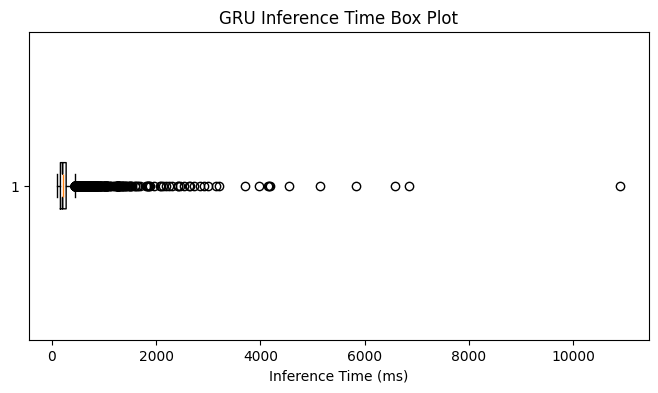

In [16]:
plt.figure(figsize=(8, 4))
plt.boxplot(df_eval['inference_time_ms'], notch=True, vert=False)
plt.title("GRU Inference Time Box Plot")
plt.xlabel("Inference Time (ms)")
plt.show()

## CNN GRU

### Battery Drain Comparison

#### Statistics

In [17]:
df_cnn = pd.read_csv("./API_CNN_GRU.csv")
df_cnn.head()

,timestamp,cpu_usage,memory_usage,temperature,battery_level,battery_charging,upload_speed_kbps,download_speed_kbps,screen_on,brightness,battery_drain,predicted_drain_average,inference_time_ms,batch
0,4/30/2026 10:09,42,66,33.4,84,0,2.372091,0.218891,1,24,-228,-284.06293,2524.913645,1
1,4/30/2026 10:09,37,66,33.4,84,0,1.236759,0.497219,1,24,-256,-310.48780,311.548437,1
2,4/30/2026 10:09,43,66,33.4,84,0,5.511522,253.716920,1,24,-236,-310.25890,222.169739,1
3,4/30/2026 10:09,43,67,33.4,84,0,1.819063,0.304796,1,24,-257,-319.87054,159.743697,1
4,4/30/2026 10:09,50,67,33.4,84,0,4.055333,2.990146,1,24,-413,-301.71088,437.896250,1


In [18]:
shift_step = 15
df_eval_cnn = df_cnn.copy()
df_eval_cnn['actual_aligned'] = (
    df_eval_cnn.groupby('batch')['battery_drain']
    .shift(-shift_step)
)
df_eval_cnn = df_eval_cnn.dropna(
    subset=['actual_aligned', 'predicted_drain_average']
)

In [19]:
df_eval_cnn[['actual_aligned', 'predicted_drain_average']].mean()

actual_aligned             -79.658423
predicted_drain_average   -102.978212
dtype: float64

In [20]:
# Not Charging
df_eval_cnn[df_eval_cnn['battery_charging'] != 1][['actual_aligned', 'predicted_drain_average']].mean()

actual_aligned            -279.779065
predicted_drain_average   -297.121872
dtype: float64

In [21]:
# Charging
df_eval_cnn[df_eval_cnn['battery_charging'] == 1][['actual_aligned', 'predicted_drain_average']].mean()

actual_aligned             1271.219000
predicted_drain_average    1207.552703
dtype: float64

In [22]:
charging_cnn = df_eval_cnn[df_eval_cnn['battery_charging'] == 1]
not_charging_cnn = df_eval_cnn[df_eval_cnn['battery_charging'] != 1]

In [23]:
result_cnn = evaluate_prediction(df_eval_cnn)
result_charging_cnn = evaluate_prediction(charging_cnn)
result_not_charging_cnn = evaluate_prediction(not_charging_cnn)

In [24]:
print("=== All ===")
print(f"MSE  : {result_cnn['MSE']:.4f}")
print(f"RMSE : {result_cnn['RMSE']:.4f}")
print(f"R2   : {result_cnn['R2']:.4f}")

print("\n=== Charging ===")
print(f"MSE  : {result_charging_cnn['MSE']:.4f}")
print(f"RMSE : {result_charging_cnn['RMSE']:.4f}")
print(f"R2   : {result_charging_cnn['R2']:.4f}")

print("\n=== Not Charging ===")
print(f"MSE  : {result_not_charging_cnn['MSE']:.4f}")
print(f"RMSE : {result_not_charging_cnn['RMSE']:.4f}")
print(f"R2   : {result_not_charging_cnn['R2']:.4f}")

=== All ===
MSE  : 102782.1380
RMSE : 320.5965
R2   : 0.7090

=== Charging ===
MSE  : 358260.8108
RMSE : 598.5489
R2   : -0.5351

=== Not Charging ===
MSE  : 64935.2133
RMSE : 254.8239
R2   : -0.0715


#### Graph

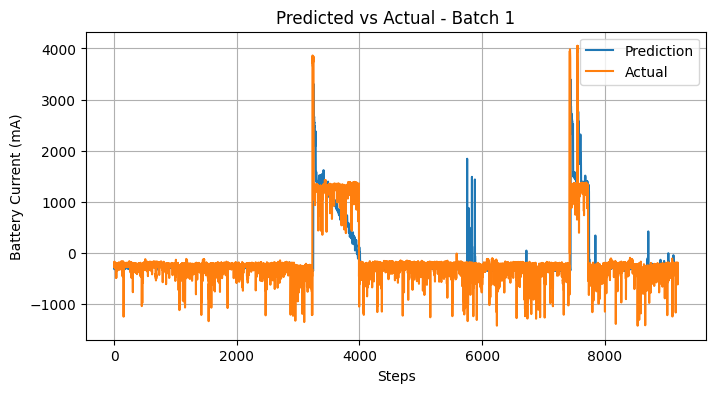

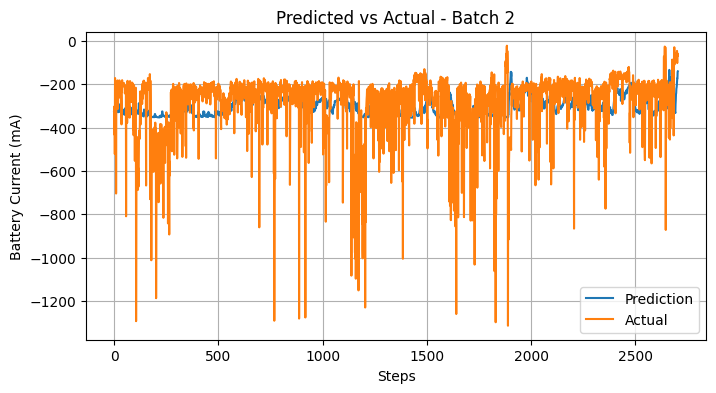

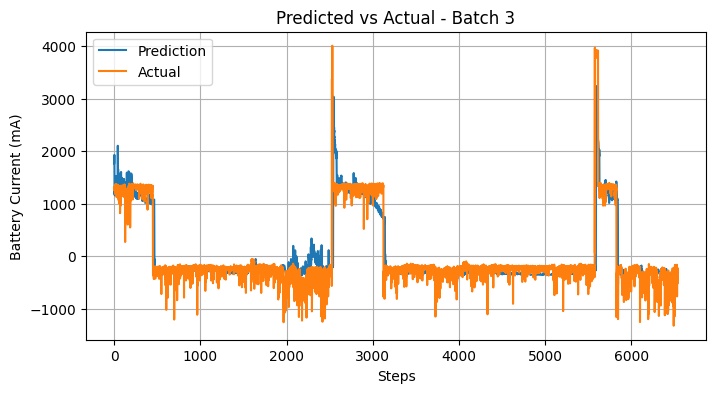

In [25]:
batch_num_cnn = df_cnn['batch'].nunique()

for i in range(1, batch_num_cnn + 1):
    batch_df_cnn = df_cnn[df_cnn['batch'] == i].copy()

    actual = batch_df_cnn['battery_drain'].shift(-shift_step)
    predicted = batch_df_cnn['predicted_drain_average']

    valid_idx = actual.notna()
    actual = actual[valid_idx].values
    predicted = predicted[valid_idx].values

    plt.figure(figsize=(8, 4))
    plt.plot(predicted, label="Prediction")
    plt.plot(actual, label="Actual")
    plt.title(f"Predicted vs Actual - Batch {i}")
    plt.xlabel("Steps")
    plt.ylabel("Battery Current (mA)")
    plt.legend()
    plt.grid(True)
    plt.show()

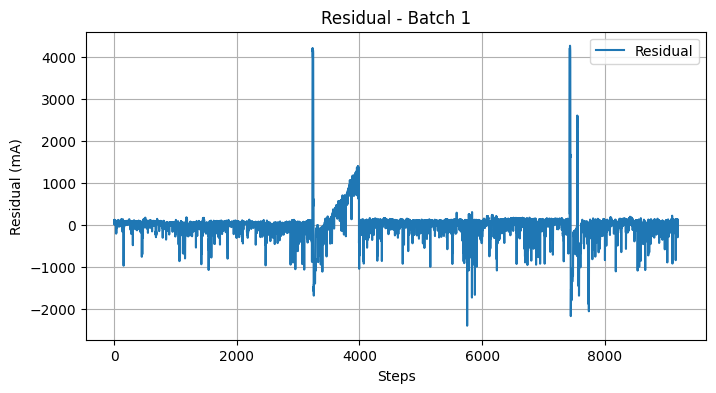

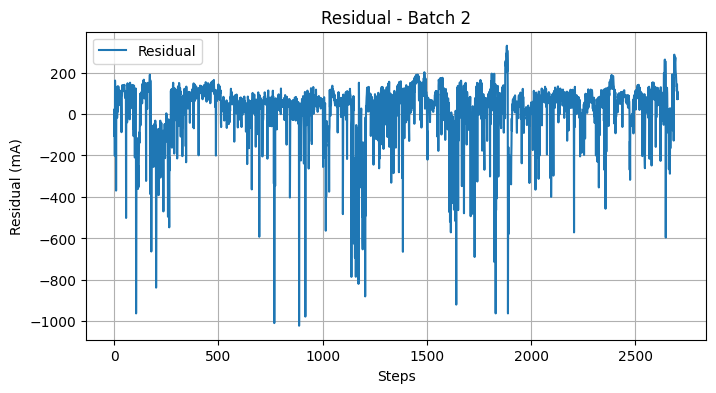

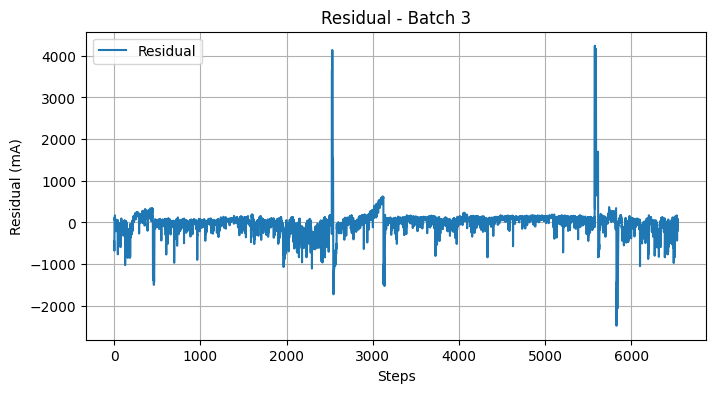

In [26]:
for i in range(1, batch_num_cnn + 1):
    batch_df_cnn = df_cnn[df_cnn['batch'] == i].copy()

    actual = batch_df_cnn['battery_drain'].shift(-shift_step)
    predicted = batch_df_cnn['predicted_drain_average']

    valid_idx = actual.notna()
    actual = actual[valid_idx].values
    predicted = predicted[valid_idx].values

    residual = actual - predicted

    plt.figure(figsize=(8, 4))
    plt.plot(residual, label="Residual")
    plt.title(f"Residual - Batch {i}")
    plt.xlabel("Steps")
    plt.ylabel("Residual (mA)")
    plt.legend()
    plt.grid(True)
    plt.show()

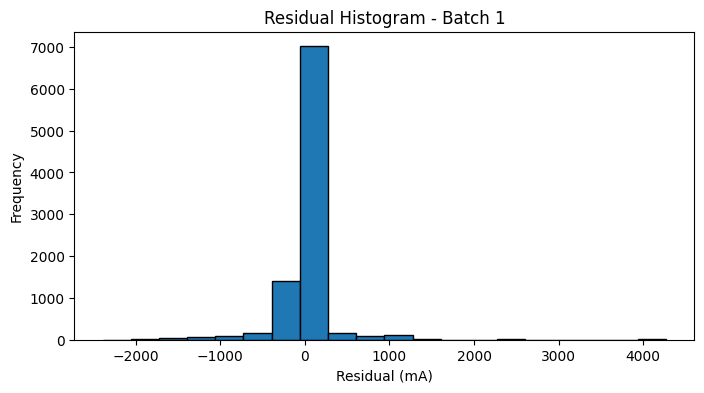

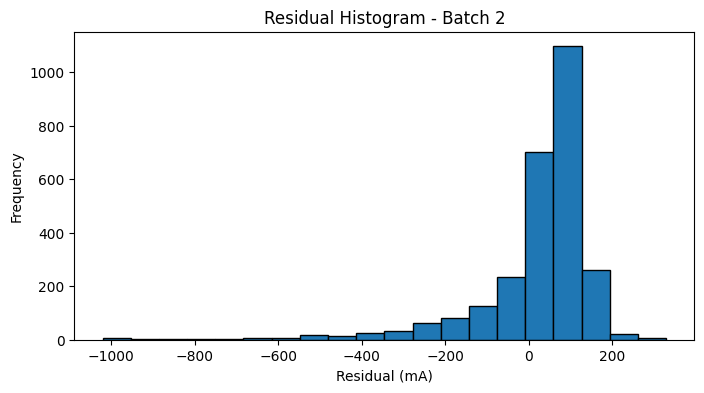

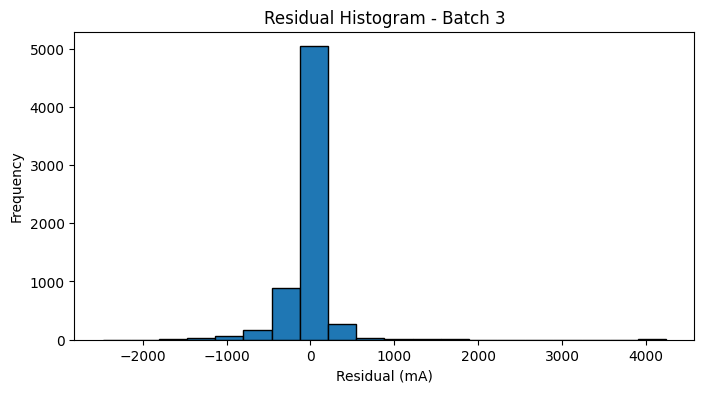

In [27]:
#Residual Histogram
for i in range(1, batch_num_cnn + 1):
    batch_df_cnn = df_cnn[df_cnn['batch'] == i].copy()

    actual = batch_df_cnn['battery_drain'].shift(-shift_step)
    predicted = batch_df_cnn['predicted_drain_average']

    valid_idx = actual.notna()
    actual = actual[valid_idx].values
    predicted = predicted[valid_idx].values

    residual = actual - predicted

    plt.figure(figsize=(8, 4))
    plt.hist(residual, bins=20, edgecolor='black')
    plt.xlabel("Residual (mA)")
    plt.ylabel("Frequency")
    plt.title(f"Residual Histogram - Batch {i}")

Correlation: 0.843162086094686


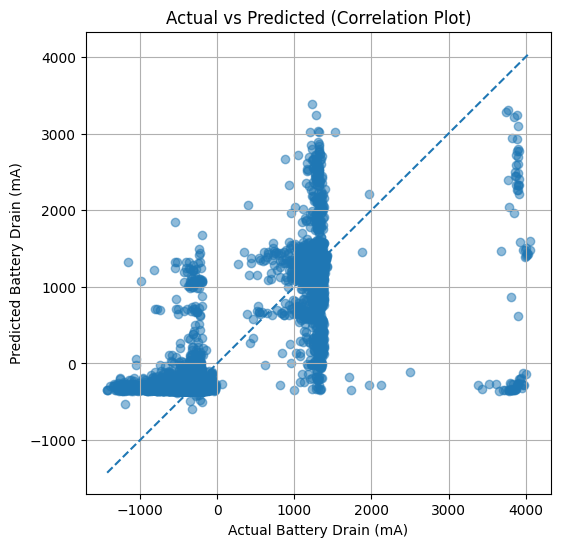

In [28]:
# Scatter Plot
actual_all = df_eval_cnn['battery_drain'].shift(-shift_step)
predicted_all = df_eval_cnn['predicted_drain_average']

valid_idx = actual_all.notna()
actual_all = actual_all[valid_idx].values
predicted_all = predicted_all[valid_idx].values

plt.figure(figsize=(6,6))
plt.scatter(actual_all, predicted_all, alpha=0.5)
min_val = min(actual_all.min(), predicted_all.min())
max_val = max(actual_all.max(), predicted_all.max())
plt.xlabel("Actual Battery Drain (mA)")
plt.ylabel("Predicted Battery Drain (mA)")
plt.title("Actual vs Predicted (Correlation Plot)")
plt.grid(True)
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')
print("Correlation:", np.corrcoef(actual_all, predicted_all)[0,1])

### Time Inference

#### Statistics

In [29]:
# Inference
df_eval_cnn['inference_time_ms'].describe()

count    18438.000000
mean       246.057986
std        213.923966
min         96.330364
25%        167.058424
50%        204.970521
75%        273.358594
max       7759.604007
Name: inference_time_ms, dtype: float64

#### Graph

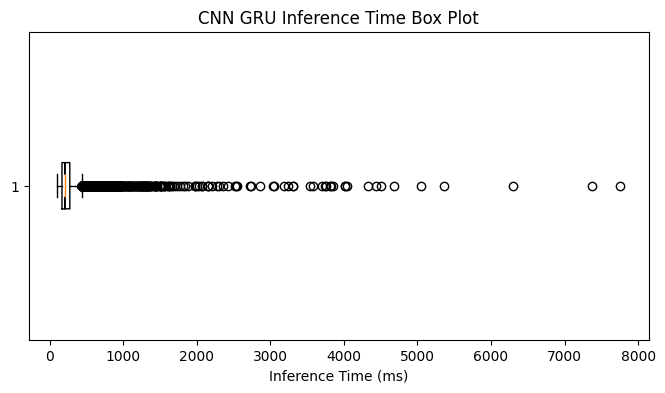

In [30]:
plt.figure(figsize=(8, 4))
plt.boxplot(df_eval_cnn['inference_time_ms'], notch=True, vert=False)
plt.title("CNN GRU Inference Time Box Plot")
plt.xlabel("Inference Time (ms)")
plt.show()